# 1. MỤC TIÊU

- Thu thập dữ liệu từ website thực tế
- Hiểu cấu trúc HTML của trang web
- Xây dựng dataset văn bản
- Xử lý tiếng Việt
- Xây dựng mô hình phân loại

# 2. PHẦN 1: THU THẬP DỮ LIỆU

## 2.1. Import

In [ ]:
import requests
from bs4 import BeautifulSoup
import json
import time

## 2.2. Lấy danh sách bài viết

In [ ]:
def get_article_links(url, max_articles=100):
    links = []

    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")

    for a in soup.find_all("a"):
        href = a.get("href")

        if href and href.startswith("https://vnexpress.net") and href.endswith(".html"):
            links.append(href)

        if len(links) >= max_articles:
            break

    return list(set(links))

## 2.3. Crawl nội dung bài báo

In [ ]:
def crawl_article(url):
    try:
        res = requests.get(url)
        soup = BeautifulSoup(res.text, "html.parser")

        title = soup.find("h1").get_text()

        paragraphs = soup.find_all("p")
        content = " ".join([p.get_text() for p in paragraphs])

        return title, content

    except:
        return None, None

## 2.4. Xây dựng dataset

In [ ]:
categories = {
    "thoi_su": "https://vnexpress.net/thoi-su",
    "kinh_te": "https://vnexpress.net/kinh-doanh"
}

data = []

for label, url in categories.items():
    print("Crawling:", label)

    links = get_article_links(url, max_articles=100)

    for link in links:
        title, content = crawl_article(link)

        if title and content:
            data.append({
                "title": title,
                "content": content,
                "label": label
            })

        time.sleep(0.5)

print("Total:", len(data))

Crawling: thoi_su
Crawling: kinh_te
Total: 70


## 2.5. Lưu dữ liệu

In [ ]:
with open("vnexpress_dataset.json", "w", encoding="utf-8") as f:
    json.dump(data, f, ensure_ascii=False, indent=2)

# 3. PHẦN 2: NLP PIPELINE

## 3.1. Load dữ liệu

In [ ]:
import pandas as pd

df = pd.read_json("/content/vnexpress_dataset.json")

df.head()

,title,content,label
0,\nĐường xuyên rừng Cần Giờ trước đề xuất mở rộ...,Đường Rừng Sác dài 35 km là tuyến độc đạo ở Cầ...,thoi_su
1,\nThả về rừng gần 200 động vật quý hiếm,Quảng TrịGần 200 động vật thuộc 17 loài chim v...,thoi_su
2,\nThủ tướng yêu cầu đẩy nhanh metro kết nối TP...,Thủ tướng yêu cầu đẩy nhanh tiến độ các tuyến ...,thoi_su
3,\nÔtô tải tông 5 xe máy ở Cà Mau,Xe tải chạy tông loạt xe máy và sạp hàng trên ...,thoi_su
4,\nChủ nhà bị chó becgie cắn tử vong,"Hà TĩnhÔng Đặng Hữu Quyết, 83 tuổi, trong lúc ...",thoi_su


## 3.2. EDA

In [ ]:
# Số lượng mỗi class
print(df["label"].value_counts())

# Độ dài văn bản (số từ)
df["length"] = df["content"].apply(lambda x: len(x.split()))

print("Mean length:", df["length"].mean())
print("Max length:", df["length"].max())
print("Min length:", df["length"].min())

label
thoi_su    35
kinh_te    35
Name: count, dtype: int64
Mean length: 698.5142857142857
Max length: 2352
Min length: 234


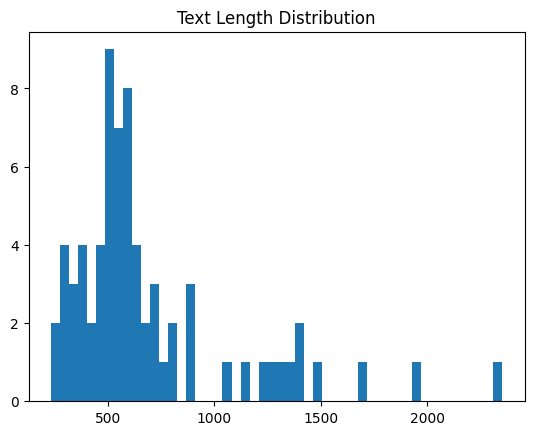

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df["length"], bins=50)
plt.title("Text Length Distribution")
plt.show()

## 3.3. Tiền xử lý tiếng Việt

In [ ]:
!pip install underthesea

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 60.1 MB/s eta 0:00:00


In [ ]:
# Import

import re
from underthesea import word_tokenize

In [ ]:
# Hàm làm sạch văn bản

def clean_text(text):
    # lower
    text = text.lower()

    # loại ký tự đặc biệt
    text = re.sub(r"[^a-zA-ZÀ-ỹ0-9\s]", " ", text)

    # loại khoảng trắng dư
    text = re.sub(r"\s+", " ", text).strip()

    return text


In [ ]:
# tokenization

def tokenize_text(text):
    return word_tokenize(text, format="text")

In [ ]:
# Pipeline preprocessing

def preprocess_pipeline(text):
    text = clean_text(text)
    text = tokenize_text(text)
    return text

In [ ]:
df["processed"] = df["content"].apply(preprocess_pipeline)

df[["content", "processed"]].head()

,content,processed
0,Đường Rừng Sác dài 35 km là tuyến độc đạo ở Cầ...,đường rừng sác dài 35 km là tuyến độc_đạo ở cầ...
1,Quảng TrịGần 200 động vật thuộc 17 loài chim v...,quảng_trịgần 200 động_vật thuộc 17 loài chim v...
2,Thủ tướng yêu cầu đẩy nhanh tiến độ các tuyến ...,thủ_tướng yêu_cầu đẩy nhanh tiến_độ các tuyến ...
3,Xe tải chạy tông loạt xe máy và sạp hàng trên ...,xe_tải chạy tông_loạt xe_máy và sạp hàng trên ...
4,"Hà TĩnhÔng Đặng Hữu Quyết, 83 tuổi, trong lúc ...",hà tĩnhông đặng_hữu_quyết 83 tuổi trong lúc ch...


## 3.4. Phân loại văn bản

### 3.4.1. Chuẩn bị dữ liệu

In [ ]:
# TODO:
# - chọn feature (processed text)
# - chọn label
# - chia train/test

from sklearn.model_selection import train_test_split

# Chọn feature là văn bản đã được tokenize và label
X = df["processed"]
y = df["label"]

# Chia tập dữ liệu (80% train, 20% test)
# stratify=y giúp giữ nguyên tỉ lệ 35/35 cho mỗi tập
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 56, Test size: 14


### 3.4.2. TF-IDF

In [ ]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# TODO:
# - khởi tạo vectorizer
# - fit_transform train
# - transform test
# - in shape

from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Khởi tạo Vectorizer với cấu hình tối ưu
tfidf = TfidfVectorizer(
    ngram_range=(1, 2), # Quan trọng: Giúp bắt được từ ghép tiếng Việt
    max_features=2000,   # Giới hạn số đặc trưng để tránh nhiễu
    min_df=2             # Loại bỏ các từ quá hiếm (chỉ xuất hiện 1 lần)
)

# 2. Học từ vựng và chuyển đổi tập Train thành dạng số
X_train_tfidf = tfidf.fit_transform(X_train)

# 3. CHỈ chuyển đổi tập Test dựa trên từ vựng đã học từ tập Train
# Đây là bước tạo ra X_test_tfidf để dùng cho hàm predict sau này
X_test_tfidf = tfidf.transform(X_test)

print("Số lượng từ vựng (features) đã học:", len(tfidf.get_feature_names_out()))
print("Kích thước ma trận tập Train:", X_train_tfidf.shape)

Số lượng từ vựng (features) đã học: 2000
Kích thước ma trận tập Train: (56, 2000)


### 3.4.3. Model

In [ ]:
# from sklearn.linear_model import LogisticRegression

# TODO:
# - khởi tạo model
# - train model

from sklearn.linear_model import LogisticRegression

# Khởi tạo mô hình Logistic Regression
# C=1.0 là tham số điều chuẩn, có thể tăng lên nếu mô hình bị underfit
model = LogisticRegression(C=1.5, solver='lbfgs', max_iter=1000)

# Huấn luyện mô hình
model.fit(X_train_tfidf, y_train)

LogisticRegression(C=1.5, max_iter=1000)

### 3.4.4. Predict

In [ ]:
# TODO:
# - dự đoán trên tập test
y_pred = model.predict(X_test_tfidf)

# Kiểm tra nhanh 5 kết quả dự đoán đầu tiên
print("Kết quả dự đoán mẫu:", y_pred[:5])
print("Nhãn thực tế tương ứng:", y_test.values[:5])

Kết quả dự đoán mẫu: ['kinh_te' 'kinh_te' 'thoi_su' 'thoi_su' 'thoi_su']
Nhãn thực tế tương ứng: ['kinh_te' 'kinh_te' 'thoi_su' 'thoi_su' 'thoi_su']


### 3.4.5. Evaluation

--- Accuracy: 100.00% ---

Classification Report:
              precision    recall  f1-score   support

     kinh_te       1.00      1.00      1.00         7
     thoi_su       1.00      1.00      1.00         7

    accuracy                           1.00        14
   macro avg       1.00      1.00      1.00        14
weighted avg       1.00      1.00      1.00        14



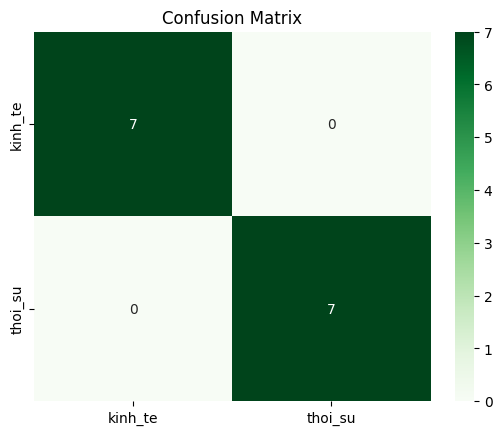

In [ ]:
# TODO:
# - accuracy
# - classification report

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Tính Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"--- Accuracy: {acc*100:.2f}% ---\n")

# In báo cáo chi tiết (Precision, Recall, F1-score)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Trực quan hóa ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.show()

### 3.4.6. Error Analysis

In [ ]:
# TODO:
# - tìm các sample sai
# - in ra:
#   + content
#   + label thật
#   + label dự đoán

# THẢO LUẬN

1. Việc tokenize tiếng Việt có ảnh hưởng lớn không?
2. Nếu không preprocess thì model sẽ thế nào?
3. TF-IDF có đủ mạnh cho bài toán này không?
4. Model sai trong trường hợp nào?